---
Phase 1-1: 線性回歸 (Linear Regression)
---

這是什麼？

最簡單的 ML 模型：用一條直線（或超平面）擬合資料。
  y = w₁x₁ + w₂x₂ + ... + b

為什麼先學它？

  1. 它包含了 ML 的所有核心概念：權重、損失函數、梯度下降
  2. 神經網路的每一層，本質上就是線性回歸 + 激活函數
  3. 簡單到能完全理解每一步在做什麼

本檔涵蓋：
  Part A: 概念解說
  Part B: NumPy 手刻（梯度下降法）
  Part C: NumPy 手刻（正規方程法 — 一步到位）
  Part D: Scikit-learn 版
  Part E: 多特徵線性回歸

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Part A: 概念解說
# ============================================================================

/home/acer/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
print("=" * 60)
print("Part A: 線性回歸的核心概念")
print("=" * 60)
print("""
問題：給定一組 (x, y) 資料點，找一條直線 y = wx + b 最好地擬合它們。

  w (weight, 權重)：直線的斜率
  b (bias, 偏差)：  直線的截距

「最好」的定義 → 損失函數 (Loss Function)：
  MSE = (1/N) Σ (y_pred - y_true)²
  讓所有預測值和真實值的「平方誤差」越小越好。

怎麼找最好的 w 和 b？
  方法 1: 梯度下降 — 一步步迭代逼近（通用方法，深度學習都用這個）
  方法 2: 正規方程 — 直接用公式算出來（只有線性回歸可以用）
""")

Part A: 線性回歸的核心概念

問題：給定一組 (x, y) 資料點，找一條直線 y = wx + b 最好地擬合它們。

  w (weight, 權重)：直線的斜率
  b (bias, 偏差)：  直線的截距

「最好」的定義 → 損失函數 (Loss Function)：
  MSE = (1/N) Σ (y_pred - y_true)²
  讓所有預測值和真實值的「平方誤差」越小越好。

怎麼找最好的 w 和 b？
  方法 1: 梯度下降 — 一步步迭代逼近（通用方法，深度學習都用這個）
  方法 2: 正規方程 — 直接用公式算出來（只有線性回歸可以用）



## 生成範例資料

In [3]:
np.random.seed(42)
N = 100
X = 2 * np.random.rand(N)              # 0~2 之間的隨機數
y_true = 3 * X + 7 + np.random.randn(N) * 0.5   # 真實關係：y = 3x + 7 + 噪音
# 我們的目標：讓模型自己學出 w≈3, b≈7

print(f"生成 {N} 個資料點")
print(f"真實關係: y = 3x + 7 + noise")
print(f"X shape: {X.shape}, y shape: {y_true.shape}")

生成 100 個資料點
真實關係: y = 3x + 7 + noise
X shape: (100,), y shape: (100,)


## Part B: NumPy 手刻 — 梯度下降法


Part B: NumPy 手刻 — 梯度下降法
初始: w=0.0, b=0.0
學習率: 0.05, 迭代次數: 100

Epoch       Loss        w        b
-----------------------------------
    0    99.5618   1.0246   0.9821
   10     2.5635   4.3551   4.6279
   20     1.2110   4.4244   5.2835
   30     0.9119   4.2120   5.5967
   40     0.7059   4.0062   5.8370
   50     0.5597   3.8301   6.0371
   60     0.4559   3.6815   6.2055
   70     0.3822   3.5562   6.3475
   80     0.3299   3.4506   6.4670
   90     0.2927   3.3616   6.5678
   99     0.2686   3.2936   6.6449

梯度下降結果: y = 3.2936x + 6.6449
真實關係:     y = 3.0000x + 7.0000


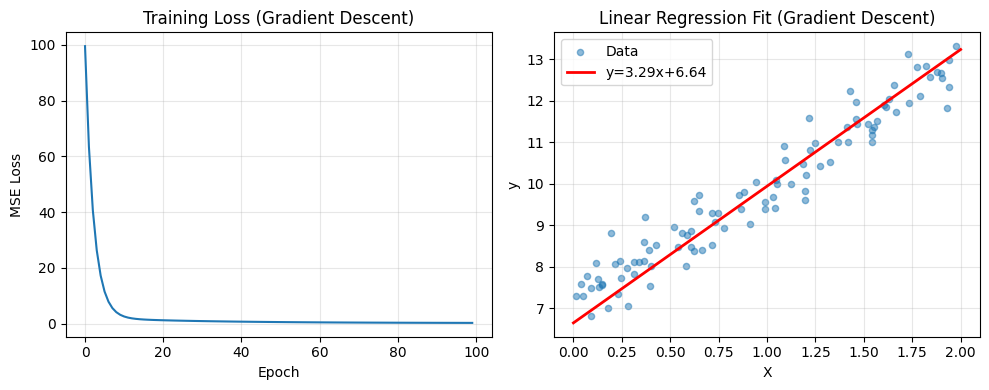

→ 圖表儲存至 plots/01_linear_regression_gd.png


In [4]:
print("\n" + "=" * 60)
print("Part B: NumPy 手刻 — 梯度下降法")
print("=" * 60)

# 初始化參數
w = 0.0    # 隨機起點
b = 0.0
learning_rate = 0.05
epochs = 100

# 記錄訓練過程
loss_history = []

print(f"初始: w={w}, b={b}")
print(f"學習率: {learning_rate}, 迭代次數: {epochs}")
print(f"\n{'Epoch':>5} {'Loss':>10} {'w':>8} {'b':>8}")
print("-" * 35)

for epoch in range(epochs):
    # ---- 前向傳播 (Forward) ----
    y_pred = w * X + b                          # 用當前 w, b 做預測

    # ---- 計算損失 ----
    loss = np.mean((y_pred - y_true) ** 2)      # MSE
    loss_history.append(loss)

    # ---- 計算梯度 (反向傳播的簡化版) ----
    # ∂Loss/∂w = (2/N) Σ (y_pred - y_true) × x
    # ∂Loss/∂b = (2/N) Σ (y_pred - y_true)
    error = y_pred - y_true                      # (N,)
    dw = (2 / N) * np.dot(error, X)             # 用向量化取代 for 迴圈
    db = (2 / N) * np.sum(error)

    # ---- 更新參數 ----
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"{epoch:5d} {loss:10.4f} {w:8.4f} {b:8.4f}")

print(f"\n梯度下降結果: y = {w:.4f}x + {b:.4f}")
print(f"真實關係:     y = 3.0000x + 7.0000")

# 畫 Loss 曲線
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss (Gradient Descent)')
plt.grid(True, alpha=0.3)

# 畫擬合結果
plt.subplot(1, 2, 2)
plt.scatter(X, y_true, alpha=0.5, s=20, label='Data')
X_line = np.linspace(0, 2, 100)
plt.plot(X_line, w * X_line + b, 'r-', linewidth=2, label=f'y={w:.2f}x+{b:.2f}')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Fit (Gradient Descent)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase-1-ml-basics/plots/01_linear_regression_gd.png', dpi=100)
plt.show()
print("→ 圖表儲存至 plots/01_linear_regression_gd.png")

## Part C: NumPy 手刻 — 正規方程 (Normal Equation)

In [5]:
print("\n" + "=" * 60)
print("Part C: NumPy 手刻 — 正規方程")
print("=" * 60)

# 正規方程：θ = (XᵀX)⁻¹ Xᵀy
# 直接算出最佳解，不需要迭代
# 缺點：當特徵數很多時，矩陣求逆很慢 (O(n³))

# 構建設計矩陣 [1, x]（加一列 1 來處理 bias）
X_b = np.column_stack([np.ones(N), X])    # shape: (100, 2)
print(f"設計矩陣 X_b shape: {X_b.shape}")
print(f"前 3 行:\n{X_b[:3]}")

# 正規方程
theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_true
b_normal, w_normal = theta[0], theta[1]

print(f"\n正規方程結果: y = {w_normal:.4f}x + {b_normal:.4f}")
print(f"梯度下降結果: y = {w:.4f}x + {b:.4f}")
print(f"真實關係:     y = 3.0000x + 7.0000")
print(f"\n→ 兩種方法得到幾乎相同的結果！")
print(f"   正規方程一步到位，梯度下降需要迭代。")
print(f"   但深度學習只能用梯度下降（模型太複雜，沒有封閉解）。")


Part C: NumPy 手刻 — 正規方程
設計矩陣 X_b shape: (100, 2)
前 3 行:
[[1.         0.74908024]
 [1.         1.90142861]
 [1.         1.46398788]]

正規方程結果: y = 2.8851x + 7.1075
梯度下降結果: y = 3.2936x + 6.6449
真實關係:     y = 3.0000x + 7.0000

→ 兩種方法得到幾乎相同的結果！
   正規方程一步到位，梯度下降需要迭代。
   但深度學習只能用梯度下降（模型太複雜，沒有封閉解）。


## Part D: Scikit-learn 版

In [6]:
print("\n" + "=" * 60)
print("Part D: Scikit-learn 版")
print("=" * 60)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# sklearn 要求 X 是 2D: (n_samples, n_features)
X_sklearn = X.reshape(-1, 1)    # (100,) → (100, 1)

# 建立模型、訓練
model = LinearRegression()
model.fit(X_sklearn, y_true)

# 取得結果
print(f"sklearn 結果:")
print(f"  w (coef_):       {model.coef_[0]:.4f}")
print(f"  b (intercept_):  {model.intercept_:.4f}")

# 預測與評估
y_pred_sk = model.predict(X_sklearn)
mse = mean_squared_error(y_true, y_pred_sk)
r2 = r2_score(y_true, y_pred_sk)
print(f"  MSE: {mse:.4f}")
print(f"  R² Score: {r2:.4f}")    # R² 越接近 1 越好，1 = 完美擬合

print(f"""
三種方法比較：
  方法         w       b       特點
  ─────────────────────────────────────────
  梯度下降   {w:7.4f}  {b:7.4f}  通用，深度學習必用
  正規方程   {w_normal:7.4f}  {b_normal:7.4f}  一步到位，只限線性模型
  sklearn    {model.coef_[0]:7.4f}  {model.intercept_:7.4f}  內部用正規方程或 SVD
  真實值     3.0000  7.0000
""")


Part D: Scikit-learn 版


sklearn 結果:
  w (coef_):       2.8851
  b (intercept_):  7.1075
  MSE: 0.2016
  R² Score: 0.9353

三種方法比較：
  方法         w       b       特點
  ─────────────────────────────────────────
  梯度下降    3.2936   6.6449  通用，深度學習必用
  正規方程    2.8851   7.1075  一步到位，只限線性模型
  sklearn     2.8851   7.1075  內部用正規方程或 SVD
  真實值     3.0000  7.0000



## Part E: 多特徵線性回歸

In [7]:
print("=" * 60)
print("Part E: 多特徵線性回歸")
print("=" * 60)

# 真實情境中通常有多個特徵
# y = 2x₁ + 3x₂ - 1x₃ + 5 + noise

np.random.seed(42)
N = 200
n_features = 3
X_multi = np.random.randn(N, n_features)
w_true = np.array([2.0, 3.0, -1.0])
b_true = 5.0
y_multi = X_multi @ w_true + b_true + np.random.randn(N) * 0.3

print(f"資料: {N} 樣本, {n_features} 特徵")
print(f"真實: y = 2x₁ + 3x₂ - 1x₃ + 5")

# --- NumPy 梯度下降版 ---
print("\n--- NumPy 梯度下降 ---")
w_gd = np.zeros(n_features)
b_gd = 0.0
lr = 0.01

for epoch in range(500):
    y_pred = X_multi @ w_gd + b_gd
    error = y_pred - y_multi

    # 多特徵的梯度
    dw = (2 / N) * (X_multi.T @ error)     # (3, N) @ (N,) = (3,)
    db = (2 / N) * np.sum(error)

    w_gd -= lr * dw
    b_gd -= lr * db

print(f"  w = {w_gd.round(4)}, b = {b_gd:.4f}")

# --- Scikit-learn 版 ---
print("\n--- Scikit-learn ---")
model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)
print(f"  w = {model_multi.coef_.round(4)}, b = {model_multi.intercept_:.4f}")

print(f"\n真實值: w = {w_true}, b = {b_true}")
print("→ 兩種方法都能學到接近真實的參數")

Part E: 多特徵線性回歸
資料: 200 樣本, 3 特徵
真實: y = 2x₁ + 3x₂ - 1x₃ + 5

--- NumPy 梯度下降 ---
  w = [ 1.993   3.0271 -0.9645], b = 5.0050

--- Scikit-learn ---
  w = [ 1.9928  3.0277 -0.9644], b = 5.0056

真實值: w = [ 2.  3. -1.], b = 5.0
→ 兩種方法都能學到接近真實的參數


## 小結

In [8]:
print("\n" + "=" * 60)
print("小結")
print("=" * 60)
print("""
線性回歸教會你的核心概念：

  概念                   對應到深度學習
  ──────────────────────────────────────────────
  y = Wx + b            →  神經網路每一層的線性部分
  MSE Loss              →  回歸問題的損失函數
  ∂Loss/∂w, ∂Loss/∂b   →  反向傳播計算的梯度
  w -= lr * gradient    →  優化器（SGD）的更新規則
  Learning Rate         →  最重要的超參數之一
  多特徵 X @ w          →  矩陣乘法 = 一層神經網路

sklearn 速查：
  from sklearn.linear_model import LinearRegression
  model = LinearRegression()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  model.coef_       # 權重
  model.intercept_  # 偏差

下一步：02_logistic_regression.py — 從回歸到分類
""")


小結

線性回歸教會你的核心概念：

  概念                   對應到深度學習
  ──────────────────────────────────────────────
  y = Wx + b            →  神經網路每一層的線性部分
  MSE Loss              →  回歸問題的損失函數
  ∂Loss/∂w, ∂Loss/∂b   →  反向傳播計算的梯度
  w -= lr * gradient    →  優化器（SGD）的更新規則
  Learning Rate         →  最重要的超參數之一
  多特徵 X @ w          →  矩陣乘法 = 一層神經網路

sklearn 速查：
  from sklearn.linear_model import LinearRegression
  model = LinearRegression()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  model.coef_       # 權重
  model.intercept_  # 偏差

下一步：02_logistic_regression.py — 從回歸到分類

